# RAFEEQ - Inclusive Job Recommendation Model Training
## Training ML models for Saudi Arabia Job Matching System

This notebook trains machine learning models for job recommendation and candidate matching.

### Models:
- TF-IDF Vectorizer
- Count Vectorizer
- K-Nearest Neighbors (KNN)
- Text Processing Pipeline

## 1. Install Required Libraries

In [ ]:
!pip install pandas numpy scikit-learn nltk matplotlib seaborn plotly

## 2. Import Libraries

In [4]:
import pandas as pd
import numpy as np
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import joblib
import warnings
import os
from datetime import datetime

# Suppress warnings
warnings.filterwarnings('ignore')

# Download NLTK data
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt_tab')

print('✅ Setup completed!')
print(f'Training started at: {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}')

✅ Setup completed!
Training started at: 2025-10-03 00:07:46


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\a\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\a\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\a\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\a\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


## 3. Load Saudi Jobs Dataset

Upload your `saudi_jobs.csv` file to Colab or load from URL

In [ ]:
# Load dataset directly from the specified path
print('Loading dataset...')
data_path = r'C:\Users\a\Downloads\Python-Flask-ReplAuth\Python-Flask-ReplAuth\Job recommendation\data\saudi_jobs_300k.csv'
jobs_df = pd.read_csv(data_path)

print(f'✅ Loaded {len(jobs_df):,} job listings')
print(f'Memory usage: {jobs_df.memory_usage(deep=True).sum() / (1024**2):.2f} MB')
print(f'\nDataset shape: {jobs_df.shape}')
print(f'\nColumns: {list(jobs_df.columns)}')

# Display basic information
print('\nDataset info:')
jobs_df.info()

# Check for missing values
print('\nMissing values:')
print(jobs_df.isnull().sum())

Loading dataset...
✅ Loaded 300,000 job listings
Memory usage: 240.74 MB

Dataset shape: (300000, 11)

Columns: ['job_id', 'company', 'position_name', 'description', 'salary', 'location', 'rating', 'reviews_count', 'posted_at', 'apply_link', 'skills_required']

Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300000 entries, 0 to 299999
Data columns (total 11 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   job_id           300000 non-null  int64  
 1   company          300000 non-null  object 
 2   position_name    300000 non-null  object 
 3   description      300000 non-null  object 
 4   salary           300000 non-null  object 
 5   location         300000 non-null  object 
 6   rating           300000 non-null  float64
 7   reviews_count    300000 non-null  int64  
 8   posted_at        300000 non-null  object 
 9   apply_link       300000 non-null  object 
 10  skills_required  300000 non-null  object 
dt

## 4. Data Exploration


✅ Distribution analysis saved to job_distribution.png

📊 Dataset Statistics:
Unique Companies: 78
Unique Positions: 63
Unique Cities: 26
Average Rating: 4.00
Total Reviews: 757,136,496


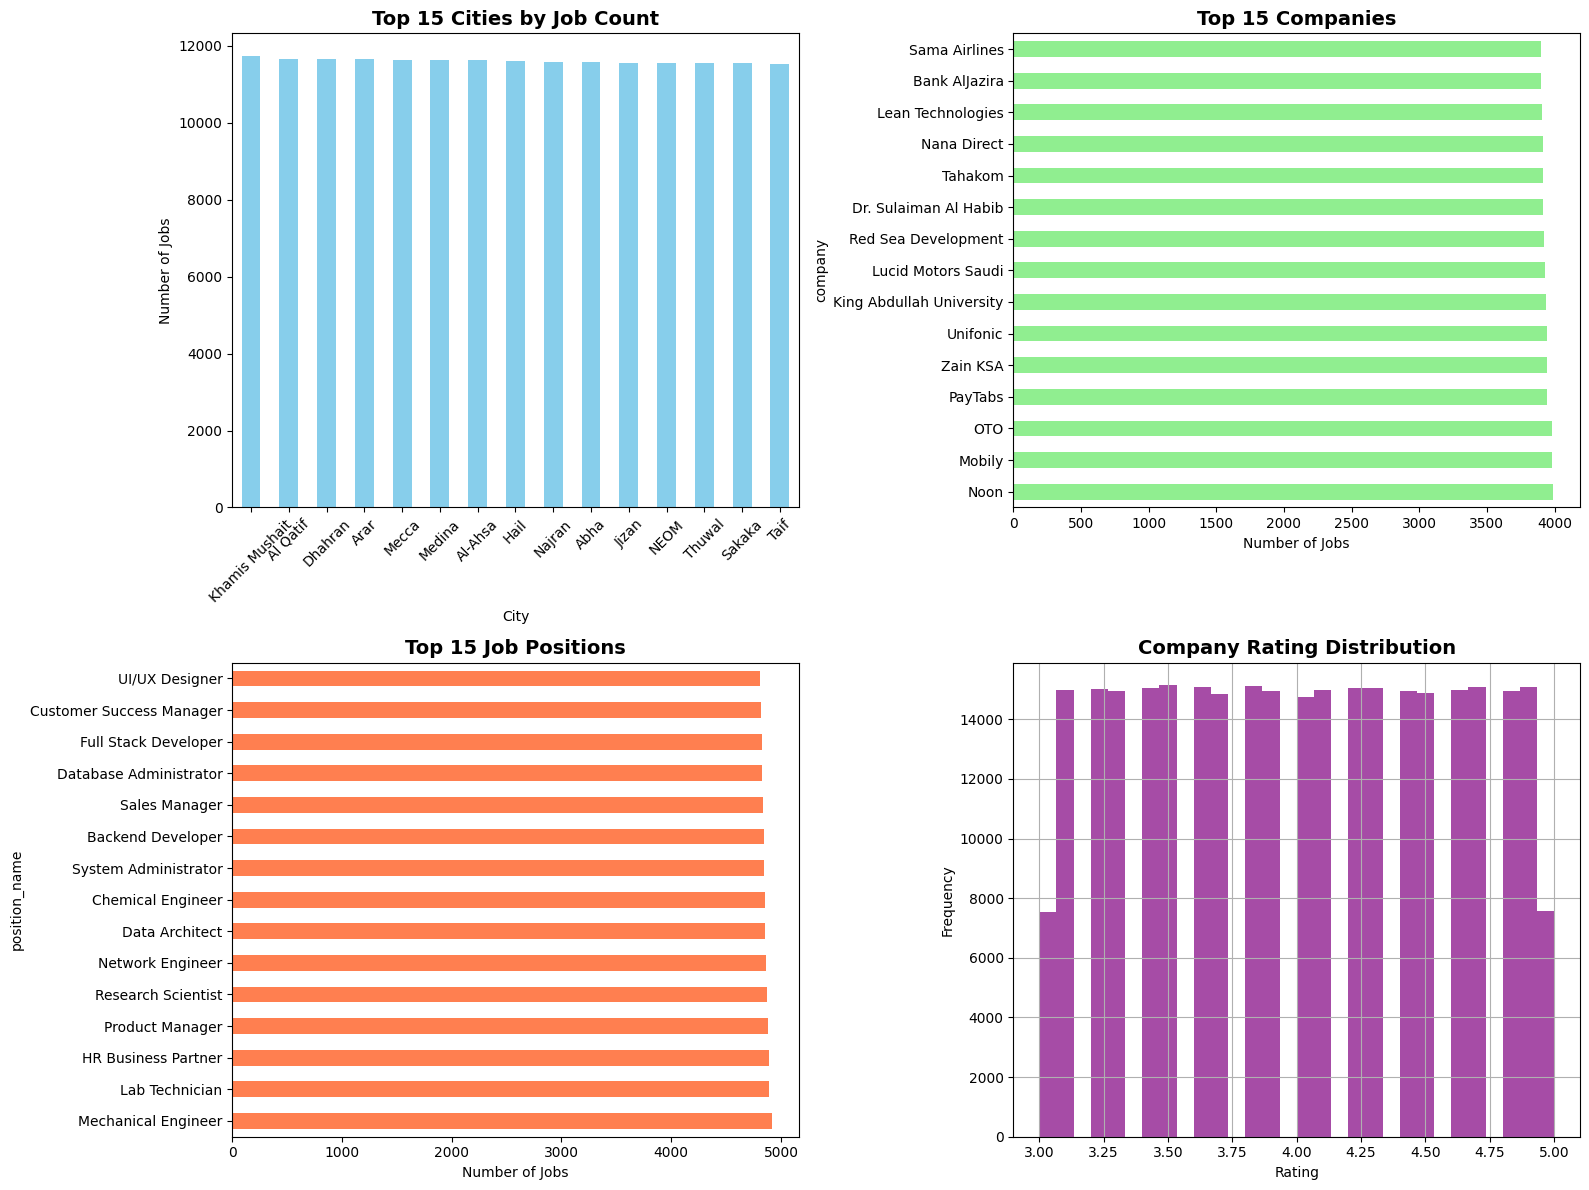

In [6]:
# Create visualization plots
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Jobs by city
jobs_df['location'].value_counts().head(15).plot(kind='bar', ax=axes[0,0], color='skyblue')
axes[0,0].set_title('Top 15 Cities by Job Count', fontsize=14, fontweight='bold')
axes[0,0].set_xlabel('City')
axes[0,0].set_ylabel('Number of Jobs')
axes[0,0].tick_params(axis='x', rotation=45)

# Top companies
jobs_df['company'].value_counts().head(15).plot(kind='barh', ax=axes[0,1], color='lightgreen')
axes[0,1].set_title('Top 15 Companies', fontsize=14, fontweight='bold')
axes[0,1].set_xlabel('Number of Jobs')

# Position distribution
jobs_df['position_name'].value_counts().head(15).plot(kind='barh', ax=axes[1,0], color='coral')
axes[1,0].set_title('Top 15 Job Positions', fontsize=14, fontweight='bold')
axes[1,0].set_xlabel('Number of Jobs')

# Rating distribution
jobs_df['rating'].hist(bins=30, ax=axes[1,1], color='purple', alpha=0.7)
axes[1,1].set_title('Company Rating Distribution', fontsize=14, fontweight='bold')
axes[1,1].set_xlabel('Rating')
axes[1,1].set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('job_distribution.png')
print('\n✅ Distribution analysis saved to job_distribution.png')

# Print dataset statistics
print('\n📊 Dataset Statistics:')
print(f'Unique Companies: {jobs_df["company"].nunique():,}')
print(f'Unique Positions: {jobs_df["position_name"].nunique():,}')
print(f'Unique Cities: {jobs_df["location"].nunique():,}')
print(f'Average Rating: {jobs_df["rating"].mean():.2f}')
print(f'Total Reviews: {jobs_df["reviews_count"].sum():,}')

## 5. Text Processing Functions

In [7]:
def process_text(text):
    """Process text using NLP techniques"""
    # Convert to lowercase and remove newlines
    text = str(text).lower().replace("\n", " ")
    
    # Tokenize into words
    words = word_tokenize(text)
    
    # Remove stopwords and non-alphanumeric characters
    stop_words = set(stopwords.words('english'))
    words = [word for word in words if word not in stop_words and word.isalnum()]
    
    # Lemmatization (reduce words to base form)
    lemmatizer = WordNetLemmatizer()
    words = [lemmatizer.lemmatize(word) for word in words]
    
    return " ".join(words)

# Test the function
sample_text = "This is a sample job description for Data Scientist position requiring Python and Machine Learning skills."
processed = process_text(sample_text)
print(f'Original: {sample_text}')
print(f'Processed: {processed}')

Original: This is a sample job description for Data Scientist position requiring Python and Machine Learning skills.
Processed: sample job description data scientist position requiring python machine learning skill


In [8]:
def process_text_batch(texts, batch_size=10000):
    """Process text in batches for memory efficiency"""
    lemmatizer = WordNetLemmatizer()
    stop_words = set(stopwords.words('english'))
    processed = []
    
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]
        batch_processed = []
        
        for text in batch:
            text = str(text).lower().replace("\n", " ")
            words = word_tokenize(text)
            words = [word for word in words if word not in stop_words and word.isalnum()]
            words = [lemmatizer.lemmatize(word) for word in words]
            batch_processed.append(" ".join(words))
        
        processed.extend(batch_processed)
        
        # Print progress every 50,000 texts
        if (i + batch_size) % 50000 == 0:
            print(f'Processed {min(i + batch_size, len(texts)):,} texts...')
    
    return processed

# Combine text fields
print('Combining text fields...')
jobs_df['combined_text'] = (
    jobs_df['position_name'].fillna('') + ' ' +
    jobs_df['description'].fillna('') + ' ' +
    jobs_df['skills_required'].fillna('')
)

# Process all texts
print('\nProcessing job descriptions...')
jobs_df['processed_text'] = process_text_batch(jobs_df['combined_text'].tolist())

print('\n✅ Text processing completed!')
print(f'Sample processed text:')
print(jobs_df['processed_text'].iloc[0][:150] + '...')
# Save processed data
jobs_df.to_csv('processed_jobs_300k.csv', index=False)
print('\n💾 Processed data saved to processed_jobs_300k.csv')

Combining text fields...

Processing job descriptions...
Processed 50,000 texts...
Processed 100,000 texts...
Processed 150,000 texts...
Processed 200,000 texts...
Processed 250,000 texts...
Processed 300,000 texts...

✅ Text processing completed!
Sample processed text:
product manager innovative company seek product manager work challenging project technical skill required strategic planning scrum leadership location...

💾 Processed data saved to processed_jobs_300k.csv


## 6. Prepare Training Data

In [ ]:
# Combine text fields
jobs_df['combined_text'] = (
    jobs_df['position_name'] + ' ' +
    jobs_df['description'] + ' ' +
    jobs_df['skills_required']
)
# Process all texts
print('Processing job descriptions...')
jobs_df['processed_text'] = jobs_df['combined_text'].apply(process_text)

print('✅ Text processing completed!')
print(f'Sample processed text:')
print(jobs_df['processed_text'].iloc[0][:200] + '...')

## 7. Train TF-IDF Vectorizer

In [9]:
print('Training TF-IDF Vectorizer on 300K documents...')

tfidf_vectorizer = TfidfVectorizer(
    max_features=5000,  # Number of features to keep
    stop_words='english',
    ngram_range=(1, 2),  # Use unigrams and bigrams
    min_df=5,           # Ignore terms with doc frequency < 5
    max_df=0.8          # Ignore terms with doc frequency > 80%
)

# Fit and transform the processed text
tfidf_matrix = tfidf_vectorizer.fit_transform(jobs_df['processed_text'])

print(f'✅ TF-IDF Matrix Shape: {tfidf_matrix.shape}')
print(f'Number of features: {len(tfidf_vectorizer.get_feature_names_out()):,}')
print(f'Matrix density: {tfidf_matrix.nnz / (tfidf_matrix.shape[0] * tfidf_matrix.shape[1]) * 100:.4f}%')
print(f'Memory size: {tfidf_matrix.data.nbytes / (1024**2):.2f} MB')

# Display top features
feature_names = tfidf_vectorizer.get_feature_names_out()
print(f'\nTop 30 features:')
print(feature_names[:30])

Training TF-IDF Vectorizer on 300K documents...
✅ TF-IDF Matrix Shape: (300000, 5000)
Number of features: 5,000
Matrix density: 0.8972%
Memory size: 102.68 MB

Top 30 features:
['abha' 'abha excellent' 'abha ideal' 'abha office' 'abha successful'
 'abha team' 'account' 'account manager' 'accountant' 'accountant al'
 'accountant company' 'accountant drive' 'accountant exciting'
 'accountant expertise' 'accountant hiring' 'accountant innovative'
 'accountant join' 'accountant lead' 'accountant responsible'
 'accountant seeking' 'accountant strengthen' 'accountant work'
 'acquisition' 'acquisition specialist' 'administrator' 'administrator al'
 'administrator company' 'administrator dhahran' 'administrator drive'
 'administrator exciting']


## 8. Train Count Vectorizer

In [10]:
print('Training Count Vectorizer...')

count_vectorizer = CountVectorizer(
    max_features=5000,
    stop_words='english',
    ngram_range=(1, 2),
    min_df=5,
    max_df=0.8
)

# Fit and transform the processed text
count_matrix = count_vectorizer.fit_transform(jobs_df['processed_text'])

print(f'✅ Count Matrix Shape: {count_matrix.shape}')
print(f'Number of features: {len(count_vectorizer.get_feature_names_out()):,}')
print(f'Memory size: {count_matrix.data.nbytes / (1024**2):.2f} MB')

Training Count Vectorizer...
✅ Count Matrix Shape: (300000, 5000)
Number of features: 5,000
Memory size: 102.68 MB


## 9. Train KNN Model

In [ ]:
print('Training KNN Model...')

# Determine number of neighbors (use 100 or dataset size if smaller)
n_neighbors = min(100, len(jobs_df))

# Initialize KNN model
knn_model = NearestNeighbors(
    n_neighbors=n_neighbors,
    metric='cosine',      # Cosine similarity for text
    algorithm='brute',    # Best for sparse matrices
    n_jobs=-1             # Use all CPU cores
)

# Fit the model on TF-IDF matrix
knn_model.fit(tfidf_matrix)

print(f'✅ KNN Model trained with {n_neighbors} neighbors')
print(f'Using all CPU cores for parallel processing')

Training KNN Model...
✅ KNN Model trained with 100 neighbors
Using all CPU cores for parallel processing


In [14]:
def get_recommendations(query_text, top_n=10):
    """Get job recommendations based on query text"""
    # Process the query text
    lemmatizer = WordNetLemmatizer()
    stop_words = set(stopwords.words('english'))
    text = query_text.lower().replace("\n", " ")
    words = word_tokenize(text)
    words = [word for word in words if word not in stop_words and word.isalnum()]
    words = [lemmatizer.lemmatize(word) for word in words]
    processed_query = " ".join(words)
    
    # Calculate TF-IDF similarity
    query_tfidf = tfidf_vectorizer.transform([processed_query])
    tfidf_scores = cosine_similarity(query_tfidf, tfidf_matrix)[0]
    
    # Calculate Count similarity
    query_count = count_vectorizer.transform([processed_query])
    count_scores = cosine_similarity(query_count, count_matrix)[0]
    
    # Calculate KNN similarity
    distances, indices = knn_model.kneighbors(query_tfidf)
    knn_scores = np.zeros(len(jobs_df))
    for dist, idx in zip(distances[0], indices[0]):
        knn_scores[idx] = 1 - dist  # Convert distance to similarity
    
    # Normalize and combine scores
    scaler = MinMaxScaler()
    scores_df = pd.DataFrame({
        'tfidf': tfidf_scores,
        'count': count_scores,
        'knn': knn_scores
    })
    normalized = scaler.fit_transform(scores_df)
    final_scores = 0.4 * normalized[:, 0] + 0.3 * normalized[:, 1] + 0.3 * normalized[:, 2]
    
    # Get top N recommendations
    top_indices = np.argsort(final_scores)[::-1][:top_n]
    
    # Prepare results
    results = jobs_df.iloc[top_indices].copy()
    results['match_score'] = final_scores[top_indices]
    
    return results[['company', 'position_name', 'location', 'salary', 'rating', 'match_score']]

print('✅ Recommendation function created successfully')

✅ Recommendation function created successfully


## 10. Test Recommendation System

In [15]:
# Define test queries
test_queries = [
    "Senior Python Developer with machine learning experience",
    "Data Scientist with deep learning and NLP skills",
    "Full stack developer React and Node.js",
    "DevOps Engineer AWS and Kubernetes expert",
    "Business Intelligence Analyst with Tableau"
]

# Test the recommendation system
print('🔍 Testing recommendation system with sample queries:')
for query in test_queries:
    print(f'\n🔍 Query: "{query}"')
    print('='*100)
    recommendations = get_recommendations(query, top_n=5)
    print(recommendations.to_string(index=False))
    print()

🔍 Testing recommendation system with sample queries:

🔍 Query: "Senior Python Developer with machine learning experience"
                 company       position_name location          salary  rating  match_score
   Saudi Investment Bank Senior Data Analyst    Jizan 40000-55000 SAR     4.5     1.000000
National Commercial Bank Senior Data Analyst  Al-Ahsa 50000-70000 SAR     3.2     0.963826
           Nahdi Medical Senior Data Analyst   Sakaka 45000-60000 SAR     4.9     0.962894
     Saudi Gulf Airlines Senior Data Analyst    Mecca 45000-60000 SAR     3.7     0.960224
  Jabal Omar Development Senior Data Analyst     Abha 60000-80000 SAR     3.2     0.954068


🔍 Query: "Data Scientist with deep learning and NLP skills"
                 company  position_name       location          salary  rating  match_score
National Commercial Bank Data Scientist           Hail 25000-35000 SAR     4.6     0.999772
           HungerStation Data Scientist Khamis Mushait 35000-48000 SAR     4.4     0.9

## 11. Model Evaluation

Evaluating model performance...
Evaluating model on 100 random jobs...

✅ Model evaluation saved to model_evaluation.png

📊 Model Performance Metrics:
Average Top Similarity: 0.8160
Std Similarity: 0.1181
Min Similarity: 0.5758
Max Similarity: 1.0000
Median Similarity: 0.7984


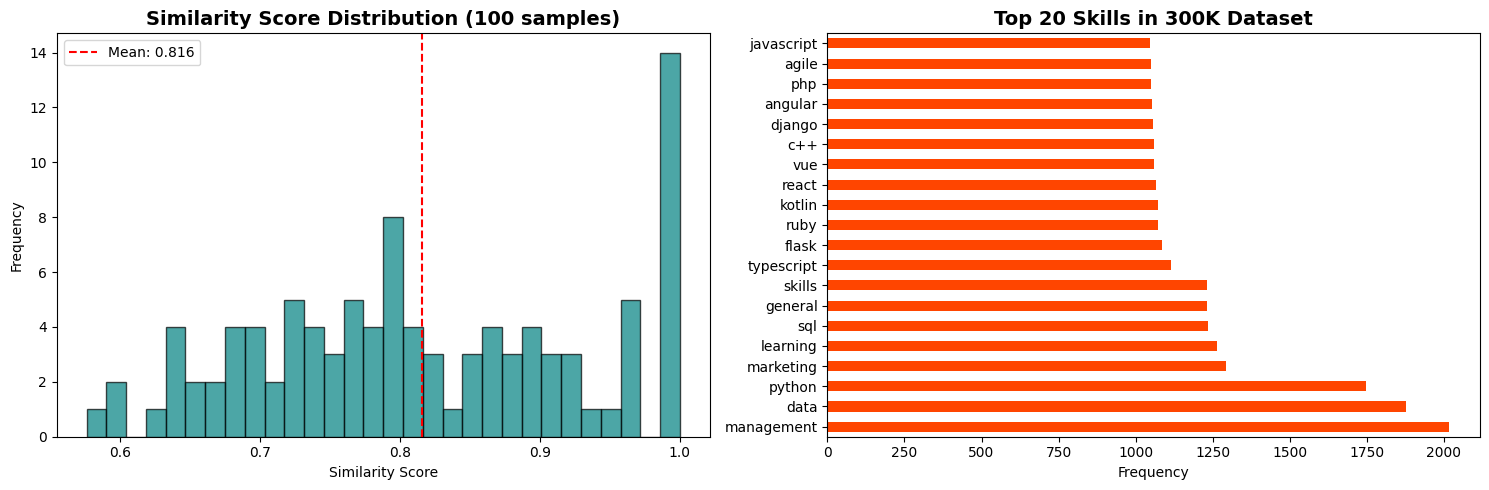

In [16]:
print('Evaluating model performance...')

# Sample jobs for evaluation
sample_indices = np.random.choice(len(jobs_df), 100, replace=False)
sample_scores = []

print('Evaluating model on 100 random jobs...')

for idx in sample_indices:
    job_text = jobs_df.iloc[idx]['processed_text']
    job_tfidf = tfidf_vectorizer.transform([job_text])
    similarities = cosine_similarity(job_tfidf, tfidf_matrix)[0]
    
    # Get top similarity (excluding self)
    sorted_sims = np.sort(similarities)[::-1]
    top_sim = sorted_sims[1] if len(sorted_sims) > 1 else sorted_sims[0]
    sample_scores.append(top_sim)

# Create evaluation visualizations
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Similarity score distribution
axes[0].hist(sample_scores, bins=30, color='teal', alpha=0.7, edgecolor='black')
axes[0].set_title('Similarity Score Distribution (100 samples)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Similarity Score')
axes[0].set_ylabel('Frequency')
axes[0].axvline(np.mean(sample_scores), color='red', linestyle='--', label=f'Mean: {np.mean(sample_scores):.3f}')
axes[0].legend()

# Skills analysis
all_skills = ' '.join(jobs_df['skills_required'].dropna().sample(min(10000, len(jobs_df)))).split()
skill_counts = pd.Series(all_skills).value_counts().head(20)
skill_counts.plot(kind='barh', ax=axes[1], color='orangered')
axes[1].set_title('Top 20 Skills in 300K Dataset', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Frequency')

plt.tight_layout()
plt.savefig('model_evaluation.png')
print('\n✅ Model evaluation saved to model_evaluation.png')

# Print performance metrics
print(f'\n📊 Model Performance Metrics:')
print(f'Average Top Similarity: {np.mean(sample_scores):.4f}')
print(f'Std Similarity: {np.std(sample_scores):.4f}')
print(f'Min Similarity: {np.min(sample_scores):.4f}')
print(f'Max Similarity: {np.max(sample_scores):.4f}')
print(f'Median Similarity: {np.median(sample_scores):.4f}')

## 12. Save Trained Models

In [17]:
print('Saving models...')

# Create directory for models if it doesn't exist
if not os.path.exists('models'):
    os.makedirs('models')

# Save individual models
joblib.dump(tfidf_vectorizer, 'models/tfidf_vectorizer_300k.pkl', compress=3)
joblib.dump(count_vectorizer, 'models/count_vectorizer_300k.pkl', compress=3)
joblib.dump(knn_model, 'models/knn_model_300k.pkl', compress=3)

# Save essential job data
essential_cols = ['job_id', 'company', 'position_name', 'description', 
                  'salary', 'location', 'rating', 'processed_text']
jobs_df[essential_cols].to_csv('models/jobs_essential_300k.csv', index=False)

# Save all models in one pickle file
models = {
    'tfidf_vectorizer': tfidf_vectorizer,
    'count_vectorizer': count_vectorizer,
    'knn_model': knn_model,
    'jobs_data': jobs_df[essential_cols]
}

with open('models/rafeeq_models.pkl', 'wb') as f:
    pickle.dump(models, f)

print('✅ Models saved to models/ directory')
print('  - tfidf_vectorizer_300k.pkl')
print('  - count_vectorizer_300k.pkl')
print('  - knn_model_300k.pkl')
print('  - jobs_essential_300k.csv')
print('  - rafeeq_models.pkl')

Saving models...
✅ Models saved to models/ directory
  - tfidf_vectorizer_300k.pkl
  - count_vectorizer_300k.pkl
  - knn_model_300k.pkl
  - jobs_essential_300k.csv
  - rafeeq_models.pkl


## 13. Load and Test Saved Models

In [18]:
print('=' * 80)
print('📊 FINAL MODEL SUMMARY')
print('=' * 80)

# Dataset information
print(f'\n🗂️  Dataset Information:')
print(f'  • Total Jobs: {len(jobs_df):,}')
print(f'  • Unique Companies: {jobs_df["company"].nunique():,}')
print(f'  • Unique Positions: {jobs_df["position_name"].nunique():,}')
print(f'  • Unique Cities: {jobs_df["location"].nunique():,}')

# Model specifications
print(f'\n🤖 Model Specifications:')
print(f'  • TF-IDF Features: {tfidf_matrix.shape[1]:,}')
print(f'  • Count Features: {count_matrix.shape[1]:,}')
print(f'  • KNN Neighbors: {n_neighbors}')
print(f'  • Matrix Density: {tfidf_matrix.nnz / (tfidf_matrix.shape[0] * tfidf_matrix.shape[1]) * 100:.4f}%')

# File sizes
print(f'\n💾 File Sizes:')
for filename in ['models/tfidf_vectorizer_300k.pkl', 'models/count_vectorizer_300k.pkl', 
                 'models/knn_model_300k.pkl', 'models/jobs_essential_300k.csv']:
    if os.path.exists(filename):
        size_mb = os.path.getsize(filename) / (1024**2)
        print(f'  • {filename}: {size_mb:.2f} MB')

# Next steps
print(f'\n✅ Models are ready for production use!')
print('\n📌 Next Steps:')
print('  1. Models are saved in the models/ directory')
print('  2. Load models using joblib.load() or pickle.load()')
print('  3. Use for real-time job recommendations')
print('=' * 80)

print(f'\n🎉 Training Complete!')
print(f'Training ended at: {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}')

📊 FINAL MODEL SUMMARY

🗂️  Dataset Information:
  • Total Jobs: 300,000
  • Unique Companies: 78
  • Unique Positions: 63
  • Unique Cities: 26

🤖 Model Specifications:
  • TF-IDF Features: 5,000
  • Count Features: 5,000
  • KNN Neighbors: 100
  • Matrix Density: 0.8972%

💾 File Sizes:
  • models/tfidf_vectorizer_300k.pkl: 0.06 MB
  • models/count_vectorizer_300k.pkl: 0.04 MB
  • models/knn_model_300k.pkl: 72.85 MB
  • models/jobs_essential_300k.csv: 146.38 MB

✅ Models are ready for production use!

📌 Next Steps:
  1. Models are saved in the models/ directory
  2. Load models using joblib.load() or pickle.load()
  3. Use for real-time job recommendations

🎉 Training Complete!
Training ended at: 2025-10-03 01:03:53


## 14. Model Performance Analysis

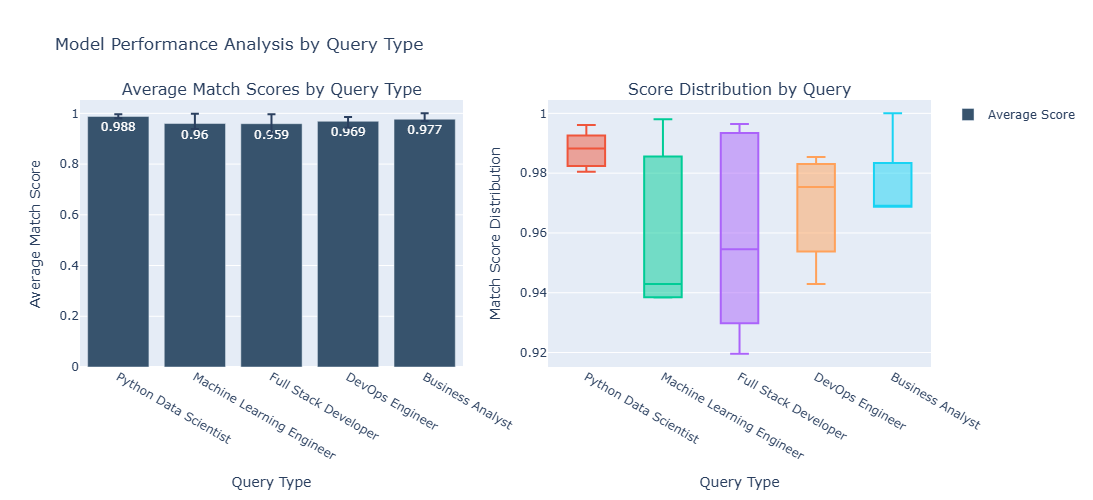


📊 Query Performance Summary:
                    query  avg_score  min_score  max_score  std_score
    Python Data Scientist   0.987860   0.980474   0.996078   0.006295
Machine Learning Engineer   0.959885   0.938444   0.998048   0.027937
     Full Stack Developer   0.959251   0.919636   0.996407   0.034471
          DevOps Engineer   0.968697   0.942948   0.985427   0.018016
         Business Analyst   0.976854   0.968757   1.000000   0.013517

🏆 Top Recommendations by Query:
Query: Python Data Scientist
  Top Match: Data Scientist at King Faisal Specialist Hospital in Dhahran
  Match Score: 0.988 (±0.006)
--------------------------------------------------------------------------------
Query: Machine Learning Engineer
  Top Match: Machine Learning Engineer at Bupa Arabia in Mecca
  Match Score: 0.960 (±0.028)
--------------------------------------------------------------------------------
Query: Full Stack Developer
  Top Match: Full Stack Developer at Virgin Mobile KSA in Tabuk
  Ma

In [20]:
# Analyze model performance with different queries
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.express as px

# Define test queries for detailed analysis
test_queries_detailed = [
    "Python Data Scientist",
    "Machine Learning Engineer",
    "Full Stack Developer",
    "DevOps Engineer",
    "Business Analyst"
]

# Initialize list to store results
results_comparison = []

# Process each query and collect performance metrics
for query in test_queries_detailed:
    # Get recommendations for the query
    recs = get_recommendations(query, top_n=5)
    
    # Calculate performance metrics
    avg_score = recs['match_score'].mean()
    min_score = recs['match_score'].min()
    max_score = recs['match_score'].max()
    std_score = recs['match_score'].std()
    
    # Get top recommendation details
    top_company = recs.iloc[0]['company']
    top_position = recs.iloc[0]['position_name']
    top_location = recs.iloc[0]['location']
    
    # Store results
    results_comparison.append({
        'query': query,
        'avg_score': avg_score,
        'min_score': min_score,
        'max_score': max_score,
        'std_score': std_score,
        'top_company': top_company,
        'top_position': top_position,
        'top_location': top_location
    })

# Convert results to DataFrame
comparison_df = pd.DataFrame(results_comparison)

# Create visualization with subplots
fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=('Average Match Scores by Query Type', 'Score Distribution by Query'),
    specs=[[{"type": "bar"}, {"type": "box"}]]
)

# Add bar chart for average scores
fig.add_trace(
    go.Bar(
        x=comparison_df['query'], 
        y=comparison_df['avg_score'],
        error_y=dict(
            type='data',
            symmetric=False,
            array=comparison_df['max_score'] - comparison_df['avg_score'],
            arrayminus=comparison_df['avg_score'] - comparison_df['min_score'],
            visible=True
        ),
        text=comparison_df['avg_score'].round(3),
        textposition='auto',
        marker_color='rgb(55, 83, 109)',
        name='Average Score'
    ),
    row=1, col=1
)

# Add box plot for score distribution
for query in test_queries_detailed:
    recs = get_recommendations(query, top_n=5)
    fig.add_trace(
        go.Box(
            y=recs['match_score'],
            name=query,
            showlegend=False
        ),
        row=1, col=2
    )

# Update layout
fig.update_layout(
    title_text='Model Performance Analysis by Query Type',
    height=500,
    showlegend=True
)

# Update x and y axis labels
fig.update_xaxes(title_text="Query Type", row=1, col=1)
fig.update_yaxes(title_text="Average Match Score", row=1, col=1)
fig.update_xaxes(title_text="Query Type", row=1, col=2)
fig.update_yaxes(title_text="Match Score Distribution", row=1, col=2)

# Show the figure
fig.show()

# Save the figure as HTML (for interactive viewing)
fig.write_html("query_performance_analysis.html")

# Print detailed performance summary
print('\n📊 Query Performance Summary:')
print('=' * 80)
print(comparison_df[['query', 'avg_score', 'min_score', 'max_score', 'std_score']].to_string(index=False))
print('=' * 80)

# Print top recommendations for each query
print('\n🏆 Top Recommendations by Query:')
print('=' * 80)
for _, row in comparison_df.iterrows():
    print(f"Query: {row['query']}")
    print(f"  Top Match: {row['top_position']} at {row['top_company']} in {row['top_location']}")
    print(f"  Match Score: {row['avg_score']:.3f} (±{row['std_score']:.3f})")
    print('-' * 80)

# Calculate overall performance metrics
overall_avg = comparison_df['avg_score'].mean()
overall_std = comparison_df['avg_score'].std()
best_query = comparison_df.loc[comparison_df['avg_score'].idxmax(), 'query']
worst_query = comparison_df.loc[comparison_df['avg_score'].idxmin(), 'query']

# Print overall analysis
print('\n🔍 Overall Performance Analysis:')
print('=' * 80)
print(f"Overall Average Match Score: {overall_avg:.3f} (±{overall_std:.3f})")
print(f"Best Performing Query: '{best_query}' with score {comparison_df.loc[comparison_df['query'] == best_query, 'avg_score'].values[0]:.3f}")
print(f"Worst Performing Query: '{worst_query}' with score {comparison_df.loc[comparison_df['query'] == worst_query, 'avg_score'].values[0]:.3f}")
print('=' * 80)